In [1]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt

In [5]:
df = pd.read_csv(r"C:\DS_AI internshisp\src\Day 29\insurance_data.csv")
df.head()

,age,bought_insurance
0,22,0
1,25,0
2,47,1
3,52,0
4,46,1


In [6]:
df.shape

(27, 2)

In [9]:
print(df.columns)

Index(['age', 'bought_insurance'], dtype='object')


In [11]:
df['bought_insurance']

0     0
1     0
2     1
3     0
4     1
5     1
6     0
7     1
8     1
9     1
10    0
11    0
12    0
13    0
14    1
15    1
16    1
17    1
18    0
19    0
20    0
21    0
22    1
23    1
24    1
25    1
26    0
Name: bought_insurance, dtype: int64

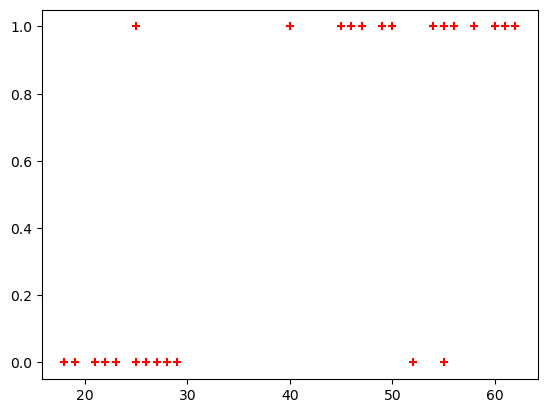

In [12]:
plt.scatter(df['age'], df['bought_insurance'], color='red', marker='+')

In [13]:
x = df[['age']]
y=df['bought_insurance']

In [14]:
from sklearn.model_selection import train_test_split

In [16]:
x_train,x_test, y_train, _test = train_test_split(x, y, train_size=0.8, random_state=10)

In [17]:
x_test

,age
7,60
5,56
18,19
21,26
11,28
1,25


In [19]:
from sklearn.linear_model import LogisticRegression
model =LogisticRegression()
model.fit(x_train,y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [20]:
model.coef_

array([[0.112778]])

In [21]:
model.intercept_

array([-4.20278276])

In [22]:
y_predicted = model.predict(x_test)

In [23]:
y_predicted

array([1, 1, 0, 0, 0, 0])

In [25]:
df['probs'] =model.predict_proba(df[['age']])[:, 1]
df

,age,bought_insurance,probs
0,22,0,0.151657
1,25,0,0.200474
2,47,1,0.749845
3,52,0,0.840463
4,46,1,0.728100
5,56,1,0.892140
6,55,0,0.880798
7,60,1,0.928502
8,62,1,0.942103
9,61,1,0.935636


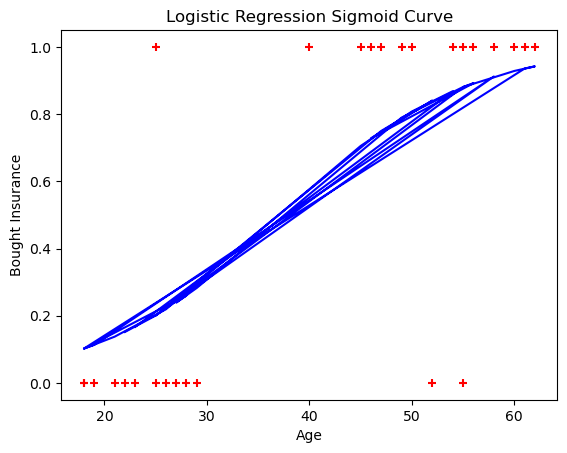

In [29]:
import matplotlib.pyplot as plt

# scatter plot (actual data)
plt.scatter(df['age'], df['bought_insurance'], color='red', marker='+')

# sigmoid curve (predicted probability)
plt.plot(df['age'], df['probs'], color='blue')

plt.xlabel("Age")
plt.ylabel("Bought Insurance")
plt.title("Logistic Regression Sigmoid Curve")

plt.show()

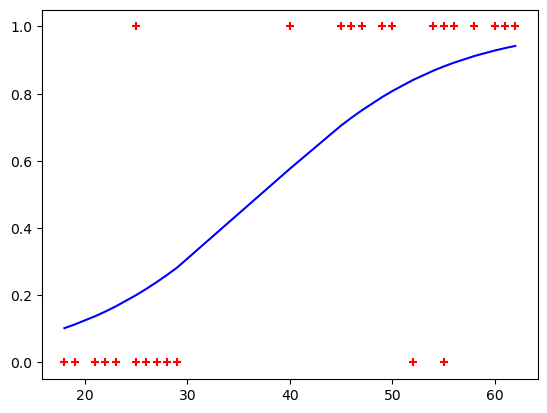

In [36]:
df_sorted = df.sort_values('age')

plt.scatter(df['age'], df['bought_insurance'], marker='+', color='red')
plt.plot(df_sorted['age'], df_sorted['probs'], color='blue')

plt.show()



In [37]:
import math
def sigmoid(x):
    return 1 / (1 + math.exp(-x))
    

In [40]:
def prediction_function(age):
 z=0.112*age+(-4.20)
 y= sigmoid(z)
 return y

In [41]:
age=35
prediction_function(age)


0.43045377606077095

In [42]:
age=40
prediction_function(age)

0.569546223939229

In [44]:
#82,66,58,77,13,1
from sklearn.metrics import accuracy_score
y_pred = model.predict(x)
accuracy = accuracy_score(y,y_pred)
print("Accuracy:", accuracy)


Accuracy: 0.8888888888888888
